In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, f_classif
from mlxtend.plotting import plot_decision_regions

# Load the dataset (2nd row has column names, but 3rd row is mistakenly included as data)
df = pd.read_csv("pd_speech_features.csv", header=1)

# Drop the first row of data because it contains column names again
df = df[1:].reset_index(drop=True)

# Check basic structure
print("First 10 column names:")
print(df.columns.tolist()[:10])

print("Last 5 column names:")
print(df.columns[-5:].tolist())

print("Shape:", df.shape)

print("First 5 rows:")
print(df.head())

print("Data Info:")
print(df.info())

First 10 column names:
['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses', 'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter']
Last 5 column names:
['tqwt_kurtosisValue_dec_33', 'tqwt_kurtosisValue_dec_34', 'tqwt_kurtosisValue_dec_35', 'tqwt_kurtosisValue_dec_36', 'class']
Shape: (755, 755)
First 5 rows:
   id  gender      PPE      DFA     RPDE  numPulses  numPeriodsPulses  \
0   0       1  0.76686  0.69481  0.53966        234               233   
1   0       1  0.85083  0.67604  0.58982        232               231   
2   1       0  0.41121  0.79672  0.59257        178               177   
3   1       0  0.32790  0.79782  0.53028        236               235   
4   1       0  0.50780  0.78744  0.65451        226               221   

   meanPeriodPulses  stdDevPeriodPulses  locPctJitter  ...  \
0          0.008258            0.000073       0.00195  ...   
1          0.008340            0.000060       0.00176  ...   
2          0.010858            0.000183    

In [2]:
# Missing values
print("Total missing values:", df.isnull().sum().sum())

# Duplicates
print("Number of duplicated rows:", df.duplicated().sum())
# Remove duplicated rows, if any
df = df.drop_duplicates().reset_index(drop=True)

# Outliers in a selected feature (e.g., PPE)
feature = 'PPE'
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df[feature] < Q1 - 1.5 * IQR) | (df[feature] > Q3 + 1.5 * IQR)]
print(f"Number of outliers in {feature}: {len(outliers)}")

Total missing values: 0
Number of duplicated rows: 1
Number of outliers in PPE: 108


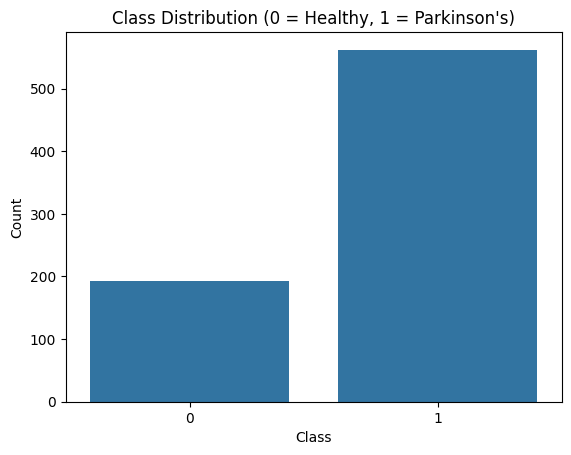

In [3]:
#Target Variable Distribution
sns.countplot(x='class', data=df)
plt.title("Class Distribution (0 = Healthy, 1 = Parkinson's)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [4]:
# 1. Feature / Target Split
X = df.drop(columns=['id', 'gender', 'class'])
y = df['class'].astype(int)

# 2. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit SelectKBest with all features (k = total number of features)
fs = SelectKBest(score_func=f_classif, k='all')
fs.fit(X_scaled, y)

# 4. Extract F-scores and feature names into a DataFrame
feature_data = []
for i in range(len(fs.scores_)):
    feature_data.append({
        'Feature Number': i,
        'Score': fs.scores_[i],
        'Feature Name': X.columns[i]
    })

fs_score_df = pd.DataFrame(feature_data)
fs_score_df = fs_score_df.sort_values(by='Score', ascending=False)

# 5. Select top 40 features for correlation filtering
top40_features = fs_score_df.head(40)['Feature Name'].tolist()

# 6. Correlation filtering (threshold = 0.7)
corr_matrix = X[top40_features].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.7)]

# 7. Remaining features after removing correlated ones
X_filtered = X[top40_features].drop(columns=to_drop)
remaining_features = X_filtered.columns.tolist()

# 8. Final 5 features selection
final_features = remaining_features[:5]

print("Final selected 5 features:", final_features)



Final selected 5 features: ['mean_MFCC_2nd_coef', 'tqwt_minValue_dec_12', 'std_8th_delta_delta', 'tqwt_kurtosisValue_dec_27', 'std_delta_delta_log_energy']


In [5]:
final_features = [
    'mean_MFCC_2nd_coef',
    'tqwt_minValue_dec_12',
    'std_8th_delta_delta',
    'tqwt_kurtosisValue_dec_27',
    'std_delta_delta_log_energy'
]

correlation_matrix = df[final_features].corr()

print("Correlation Matrix of Final Selected Features:")
print(correlation_matrix)

Correlation Matrix of Final Selected Features:
                            mean_MFCC_2nd_coef  tqwt_minValue_dec_12  \
mean_MFCC_2nd_coef                    1.000000              0.565782   
tqwt_minValue_dec_12                  0.565782              1.000000   
std_8th_delta_delta                   0.235763              0.332308   
tqwt_kurtosisValue_dec_27            -0.318991             -0.294974   
std_delta_delta_log_energy            0.187551              0.231487   

                            std_8th_delta_delta  tqwt_kurtosisValue_dec_27  \
mean_MFCC_2nd_coef                     0.235763                  -0.318991   
tqwt_minValue_dec_12                   0.332308                  -0.294974   
std_8th_delta_delta                    1.000000                  -0.256215   
tqwt_kurtosisValue_dec_27             -0.256215                   1.000000   
std_delta_delta_log_energy             0.511744                  -0.182597   

                            std_delta_delta_log_ene

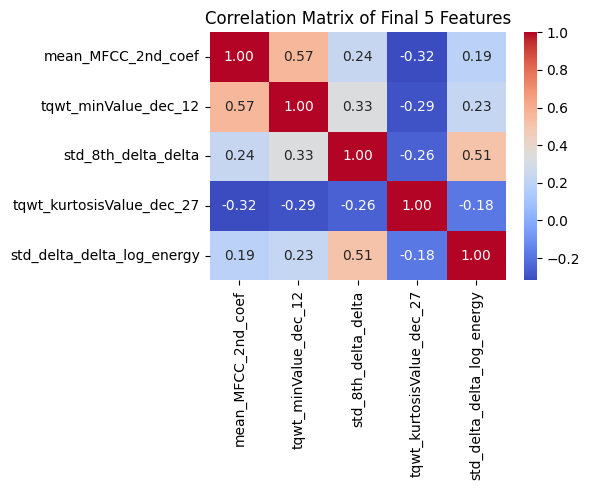

In [6]:
# 9. Optional: visualize correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(X[final_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Final 5 Features")
plt.tight_layout()
plt.show()

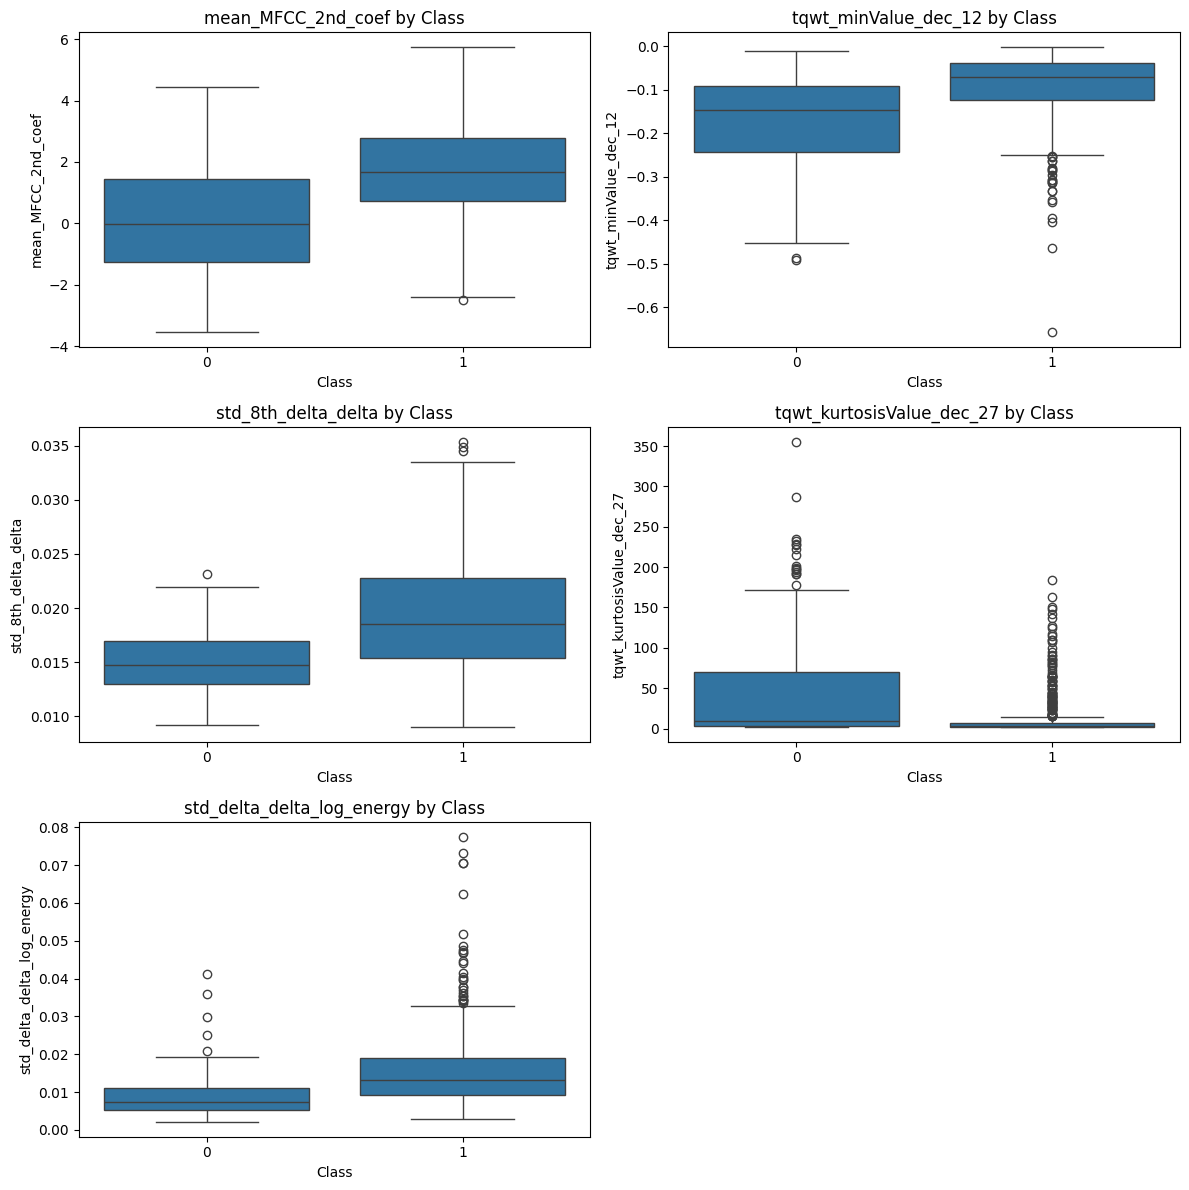

In [7]:
# Final selected features from ANOVA + correlation filtering
selected_features = [
    'mean_MFCC_2nd_coef', 'tqwt_minValue_dec_12', 'std_8th_delta_delta', 'tqwt_kurtosisValue_dec_27', 'std_delta_delta_log_energy'
]

# Boxplot visualization for each feature by class
n_cols = 2
n_rows = (len(selected_features) + 1) // n_cols

plt.figure(figsize=(12, 4 * n_rows))

for i, feature in enumerate(selected_features):
    if feature in df.columns:
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(x='class', y=feature, data=df)
        plt.title(f"{feature} by Class")
        plt.xlabel("Class")
        plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [8]:
# 1. Select features and target
selected_features = ['mean_MFCC_2nd_coef', 'tqwt_minValue_dec_12', 'std_8th_delta_delta', 'tqwt_kurtosisValue_dec_27', 'std_delta_delta_log_energy']
X = df[selected_features]
y = df["class"]

# 2. Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-Test Split (Stratified)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42)

Test Accuracy: 81.06%

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.48      0.57        58
           1       0.84      0.92      0.88       169

    accuracy                           0.81       227
   macro avg       0.76      0.70      0.72       227
weighted avg       0.80      0.81      0.80       227



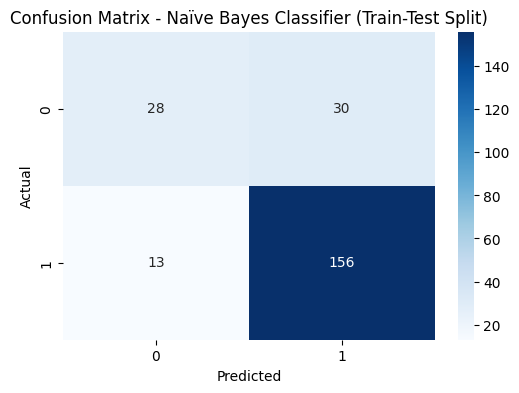

In [9]:
# 4. Train Naïve Bayes Model
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 5. Predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naïve Bayes Classifier (Train-Test Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix


# 1. Select the five features (same as those used in the Naïve Bayes model)
selected_features = ['mean_MFCC_2nd_coef', 'tqwt_minValue_dec_12', 'std_8th_delta_delta', 'tqwt_kurtosisValue_dec_27', 'std_delta_delta_log_energy']
X = df[selected_features]
y = df['class']

# 2. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split the dataset into training and testing sets (70/30 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)


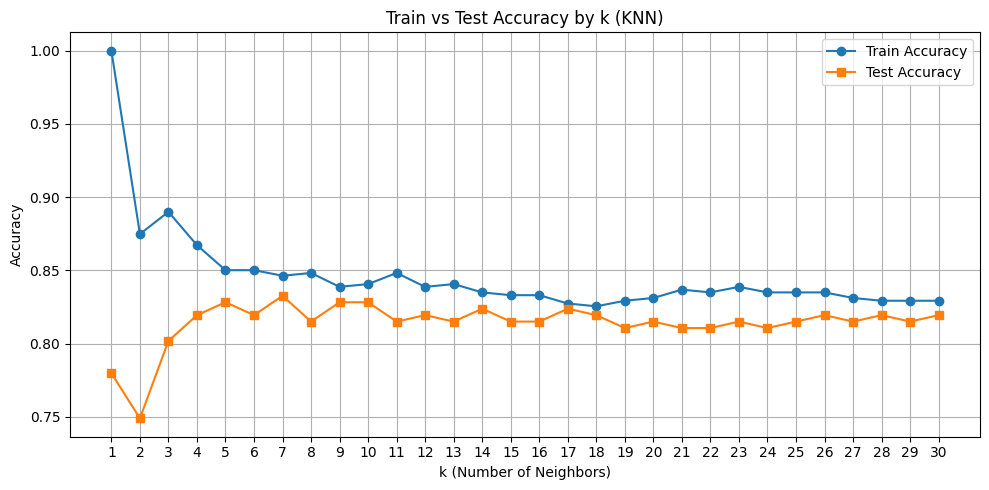

In [11]:
train_accuracies = []
test_accuracies = []

k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(k_range, test_accuracies, marker='s', label='Test Accuracy')

plt.title("Train vs Test Accuracy by k (KNN)")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Test Accuracy: 83.26%
Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.78      0.48      0.60        58
           1       0.84      0.95      0.89       169

    accuracy                           0.83       227
   macro avg       0.81      0.72      0.75       227
weighted avg       0.83      0.83      0.82       227



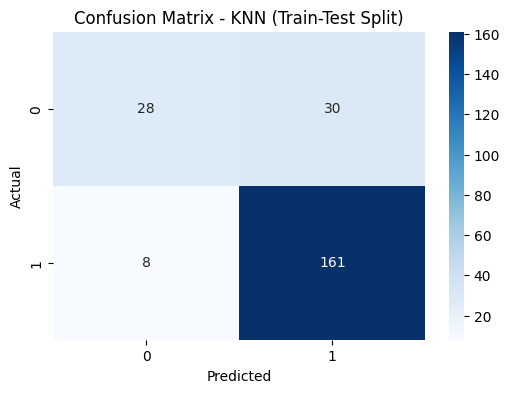

In [12]:
# 4. Train the KNN model (using k = 7)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

# 5. Predict on the test set
y_pred = knn.predict(X_test)

# 6. Evaluate the model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")
print("Classification Report (KNN):\n", classification_report(y_test, y_pred))

# 7. Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN (Train-Test Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

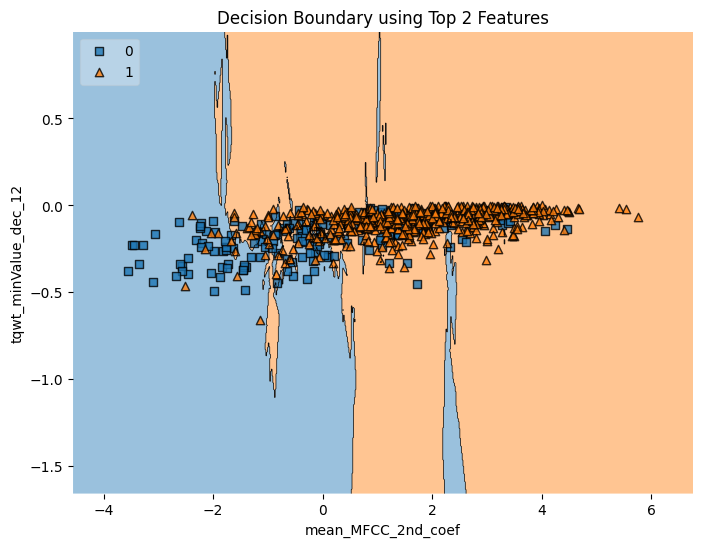

In [13]:
from sklearn.preprocessing import LabelEncoder
# Top 2 Features
top2_features = ['mean_MFCC_2nd_coef', 'tqwt_minValue_dec_12']
X_top2 = df[top2_features].values

target = df['class']
le = LabelEncoder()
y_array = le.fit_transform(target)

# k=7
knn_final = KNeighborsClassifier(n_neighbors=7)
knn_final.fit(X_top2, y_array)

# Decision Boundary Visualization
plt.figure(figsize=(8, 6))
plot_decision_regions(X=X_top2, y=y_array, clf=knn_final, legend=2)
plt.title("Decision Boundary using Top 2 Features")
plt.xlabel("mean_MFCC_2nd_coef")
plt.ylabel("tqwt_minValue_dec_12")
plt.show()

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# 1. Select features and target
selected_features = ['mean_MFCC_2nd_coef', 'tqwt_minValue_dec_12', 
                     'std_8th_delta_delta', 'tqwt_kurtosisValue_dec_27', 
                     'std_delta_delta_log_energy']

X = df[selected_features]
y = df["class"]

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Prepare 10-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 4. Try different k values
k_values = [5, 10, 15, 20, 25]
results = []

for k in k_values:
    all_predictions = np.array([])
    all_actuals = np.array([])
    fold_accuracies = []

    mlp = MLPClassifier(hidden_layer_sizes=(k,), random_state=42, max_iter=1000)

    for train_idx, test_idx in kfold.split(X_scaled, y):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_test)

        fold_acc = accuracy_score(y_test, y_pred)
        fold_accuracies.append(fold_acc)

        all_predictions = np.append(all_predictions, y_pred)
        all_actuals = np.append(all_actuals, y_test)

    final_acc = accuracy_score(all_actuals, all_predictions)
    results.append((k, final_acc))

# 5. Display results
print("Accuracy by number of neurons (k):")
for k, acc in results:
    print(f"k = {k}, Accuracy = {acc:.4f}")


Accuracy by number of neurons (k):
k = 5, Accuracy = 0.8369
k = 10, Accuracy = 0.8329
k = 15, Accuracy = 0.8263
k = 20, Accuracy = 0.8302
k = 25, Accuracy = 0.8289


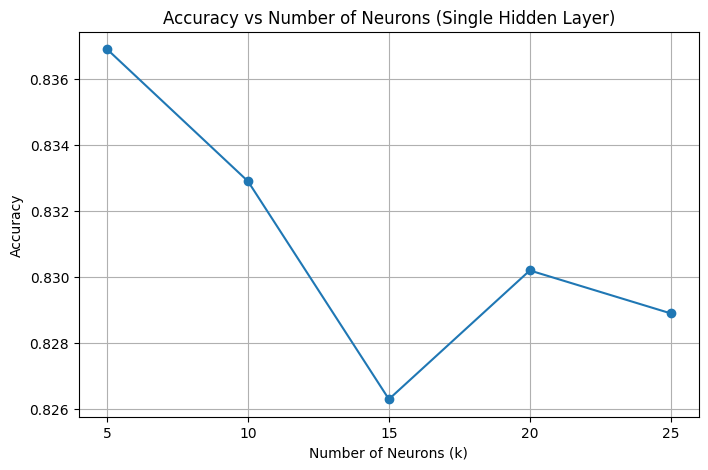

In [1]:
import matplotlib.pyplot as plt

k_values = [5, 10, 15, 20, 25]
accuracies = [0.8369, 0.8329, 0.8263, 0.8302, 0.8289]

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title('Accuracy vs Number of Neurons (Single Hidden Layer)')
plt.xlabel('Number of Neurons (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [15]:
# 1. Initialize the MLPClassifier with default parameters and 5 hidden neurons
mlp = MLPClassifier(hidden_layer_sizes=(5,), random_state=42, max_iter=1000, verbose=True)

# 2. Prepare arrays to track predictions and performance
all_predictions = np.array([])
all_actuals = np.array([])
fold_accuracies = []

best_accuracy = 0
best_iteration = 0

# 3. Perform 10-fold Stratified Cross-Validation
for train_idx, test_idx in kfold.split(X_scaled, y):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)

    fold_acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(fold_acc)

    all_predictions = np.append(all_predictions, y_pred)
    all_actuals = np.append(all_actuals, y_test)

    print("Model stopped at iteration:", mlp.n_iter_)
    print(f"Fold test accuracy: {fold_acc:.3f}")

    # Update best accuracy and corresponding iteration if applicable
    if fold_acc > best_accuracy:
        best_accuracy = fold_acc
        best_iteration = mlp.n_iter_

# 4 Compute final metrics
average_accuracy = accuracy_score(all_actuals, all_predictions)
print(f"Average MLP Accuracy (10-fold CV): {average_accuracy:.4f}")
print(f"Best Fold Accuracy: {best_accuracy:.4f}")
print(f"Corresponding Iteration Count (Best Number of Iterations): {best_iteration}")

Iteration 1, loss = 0.78082462
Iteration 2, loss = 0.77210649
Iteration 3, loss = 0.76377852
Iteration 4, loss = 0.75569584
Iteration 5, loss = 0.74795235
Iteration 6, loss = 0.74029149
Iteration 7, loss = 0.73311358
Iteration 8, loss = 0.72609966
Iteration 9, loss = 0.71930092
Iteration 10, loss = 0.71268967
Iteration 11, loss = 0.70631396
Iteration 12, loss = 0.70063917
Iteration 13, loss = 0.69457330
Iteration 14, loss = 0.68922003
Iteration 15, loss = 0.68356983
Iteration 16, loss = 0.67835106
Iteration 17, loss = 0.67322509
Iteration 18, loss = 0.66832712
Iteration 19, loss = 0.66316856
Iteration 20, loss = 0.65856940
Iteration 21, loss = 0.65389216
Iteration 22, loss = 0.64935642
Iteration 23, loss = 0.64502514
Iteration 24, loss = 0.64087340
Iteration 25, loss = 0.63656101
Iteration 26, loss = 0.63252147
Iteration 27, loss = 0.62843588
Iteration 28, loss = 0.62442368
Iteration 29, loss = 0.62045121
Iteration 30, loss = 0.61659962
Iteration 31, loss = 0.61283116
Iteration 32, los

Fold 1 finished. Final training loss: 0.3901 | Validation Accuracy: 0.7895
Fold 2 finished. Final training loss: 0.3936 | Validation Accuracy: 0.8684
Fold 3 finished. Final training loss: 0.3860 | Validation Accuracy: 0.8421
Fold 4 finished. Final training loss: 0.3823 | Validation Accuracy: 0.7895
Fold 5 finished. Final training loss: 0.3901 | Validation Accuracy: 0.8933
Fold 6 finished. Final training loss: 0.3998 | Validation Accuracy: 0.9200
Fold 7 finished. Final training loss: 0.3915 | Validation Accuracy: 0.8533
Fold 8 finished. Final training loss: 0.3814 | Validation Accuracy: 0.8133
Fold 9 finished. Final training loss: 0.3894 | Validation Accuracy: 0.8133
Fold 10 finished. Final training loss: 0.3859 | Validation Accuracy: 0.7867


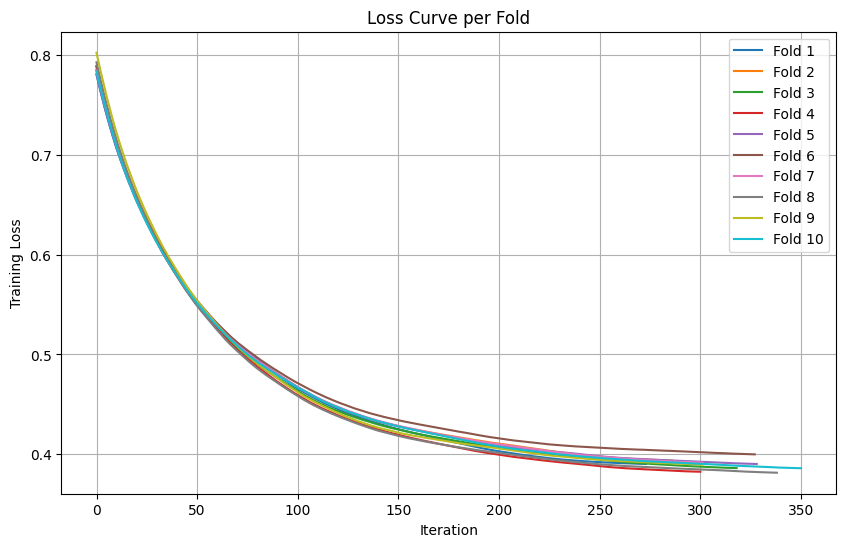


Average Validation Accuracy across 10 folds: 0.8369


In [16]:
# Track loss curves and validation accuracy
loss_curves = []
val_accuracies = []

# 10-fold stratified cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_scaled, y)):
    # Initialize model for each fold
    mlp = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42, verbose=False)
    
    # Train-test split
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train model
    mlp.fit(X_train, y_train)

    # Store training loss and validation accuracy
    loss_curves.append(mlp.loss_curve_)
    
    # validation accuracy 저장
    val_accuracy = mlp.score(X_test, y_test)
    val_accuracies.append(val_accuracy)
    
    print(f"Fold {fold+1} finished. Final training loss: {mlp.loss_curve_[-1]:.4f} | Validation Accuracy: {val_accuracy:.4f}")

# Plot loss curves
plt.figure(figsize=(10, 6))
for i, curve in enumerate(loss_curves):
    plt.plot(curve, label=f"Fold {i+1}")
plt.title("Loss Curve per Fold")
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Print average validation accuracy
avg_val_acc = np.mean(val_accuracies)
print(f"\nAverage Validation Accuracy across 10 folds: {avg_val_acc:.4f}")

In [17]:
# Store results for each architecture
architecture_results = []

# Test different splits of 5 neurons across two hidden layers
# Configurations: (4,1), (3,2), (2,3), (1,4)
for i in range(1, 5):
    h1 = 5 - i
    h2 = i
    acc_scores = []

     # 10-fold stratified cross-validation
    for train_idx, test_idx in kfold.split(X_scaled, y):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Train MLP with current architecture
        mlp = MLPClassifier(hidden_layer_sizes=(h1, h2), max_iter=1000, random_state=42)
        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_test)

        # Record accuracy
        acc = accuracy_score(y_test, y_pred)
        acc_scores.append(acc)

    # Store average accuracy for the current architecture
    mean_acc = np.mean(acc_scores)
    architecture_results.append(((h1, h2), mean_acc))

# Print architecture results
print("Neuron Split (Layer1, Layer2) | Accuracy")
for arch, acc in architecture_results:
    print(f"\t{arch[0]}, {arch[1]} \t\t\t {acc:.4f}")

Neuron Split (Layer1, Layer2) | Accuracy
	4, 1 			 0.7587
	3, 2 			 0.8144
	2, 3 			 0.8250
	1, 4 			 0.8290


Test Accuracy: 83.69%
Classification Report (MLP - 10-fold CV):
              precision    recall  f1-score   support

         0.0       0.76      0.53      0.62       192
         1.0       0.85      0.94      0.90       562

    accuracy                           0.84       754
   macro avg       0.81      0.74      0.76       754
weighted avg       0.83      0.84      0.83       754



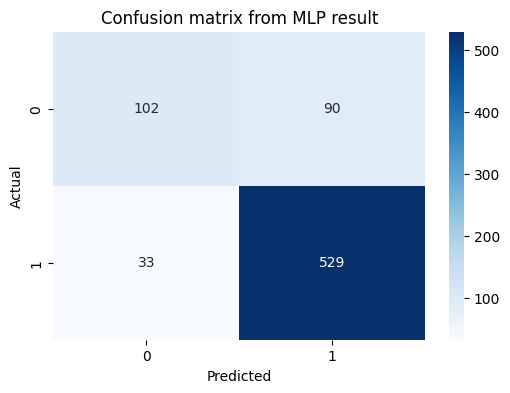

In [18]:
# Evaluate overall performance using accuracy and classification report
accuracy = accuracy_score(all_actuals, all_predictions)
print(f"Test Accuracy: {accuracy:.2%}")
print("Classification Report (MLP - 10-fold CV):")
print(classification_report(all_actuals, all_predictions))

# Generate and plot the confusion matrix
cm = confusion_matrix(all_actuals, all_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix from MLP result")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()